In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("D:\SIT\Sem.5\PBL V\Datasets\Indian_crop_production_yield_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\SHANTANU\AppData\Local\Temp\ipykernel_23964\3240414179.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\SIT\Sem.5\PBL V\Datasets\Indian_crop_production_yield_dataset.csv")


In [ ]:
df.head(2)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     575879 non-null  object 
 1   District_Name  575879 non-null  object 
 2   Crop_Year      575879 non-null  int64  
 3   Season         575879 non-null  object 
 4   Crop           575879 non-null  object 
 5   Area           575879 non-null  float64
 6   Production     575879 non-null  float64
 7   yield          575879 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 35.1+ MB


In [ ]:
df['State_Name'].value_counts()

State_Name
Uttar Pradesh                  77804
Madhya Pradesh                 52007
Karnataka                      48393
Bihar                          43555
Assam                          32798
Rajasthan                      31760
Tamil Nadu                     31312
Maharashtra                    30042
Odisha                         29625
Andhra Pradesh                 25719
Chhattisgarh                   25095
Gujarat                        22316
West Bengal                    16194
Uttarakhand                    11453
Haryana                        10844
Telangana                      10253
Nagaland                        9578
Kerala                          8629
Himachal Pradesh                7411
Punjab                          7229
Meghalaya                       7189
Arunachal Pradesh               6889
Jharkhand                       6257
Jammu and Kashmir               5974
Manipur                         4358
Tripura                         3969
Mizoram                    

In [ ]:
df.shape

In [ ]:
print(df.describe())

           Crop_Year          Area    Production         yield
count  575879.000000  5.758790e+05  5.758790e+05  5.758790e+05
mean     2007.559402  1.186614e+04  5.689498e+07  4.779376e+03
std         6.174890  4.407750e+04  1.656008e+09  7.109329e+04
min      1997.000000  8.000000e-03  0.000000e+00  0.000000e+00
25%      2002.000000  8.200000e+01  7.270000e+02  1.346025e+00
50%      2007.000000  5.870000e+02  1.220000e+04  4.484848e+01
75%      2013.000000  4.388000e+03  1.859000e+05  1.314807e+02
max      2020.000000  8.580100e+06  1.597800e+11  4.395833e+06


In [ ]:
print(df.isnull().sum())

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64


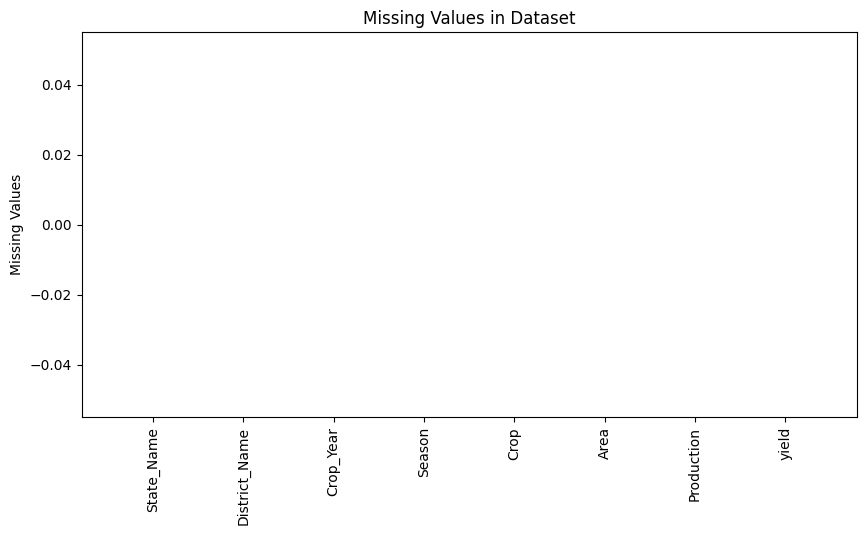

In [ ]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))

plt.bar(missing.index, missing.values)

plt.xticks(rotation=90)

plt.ylabel("Missing Values")

plt.title("Missing Values in Dataset")

plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# df = df.drop_duplicates()

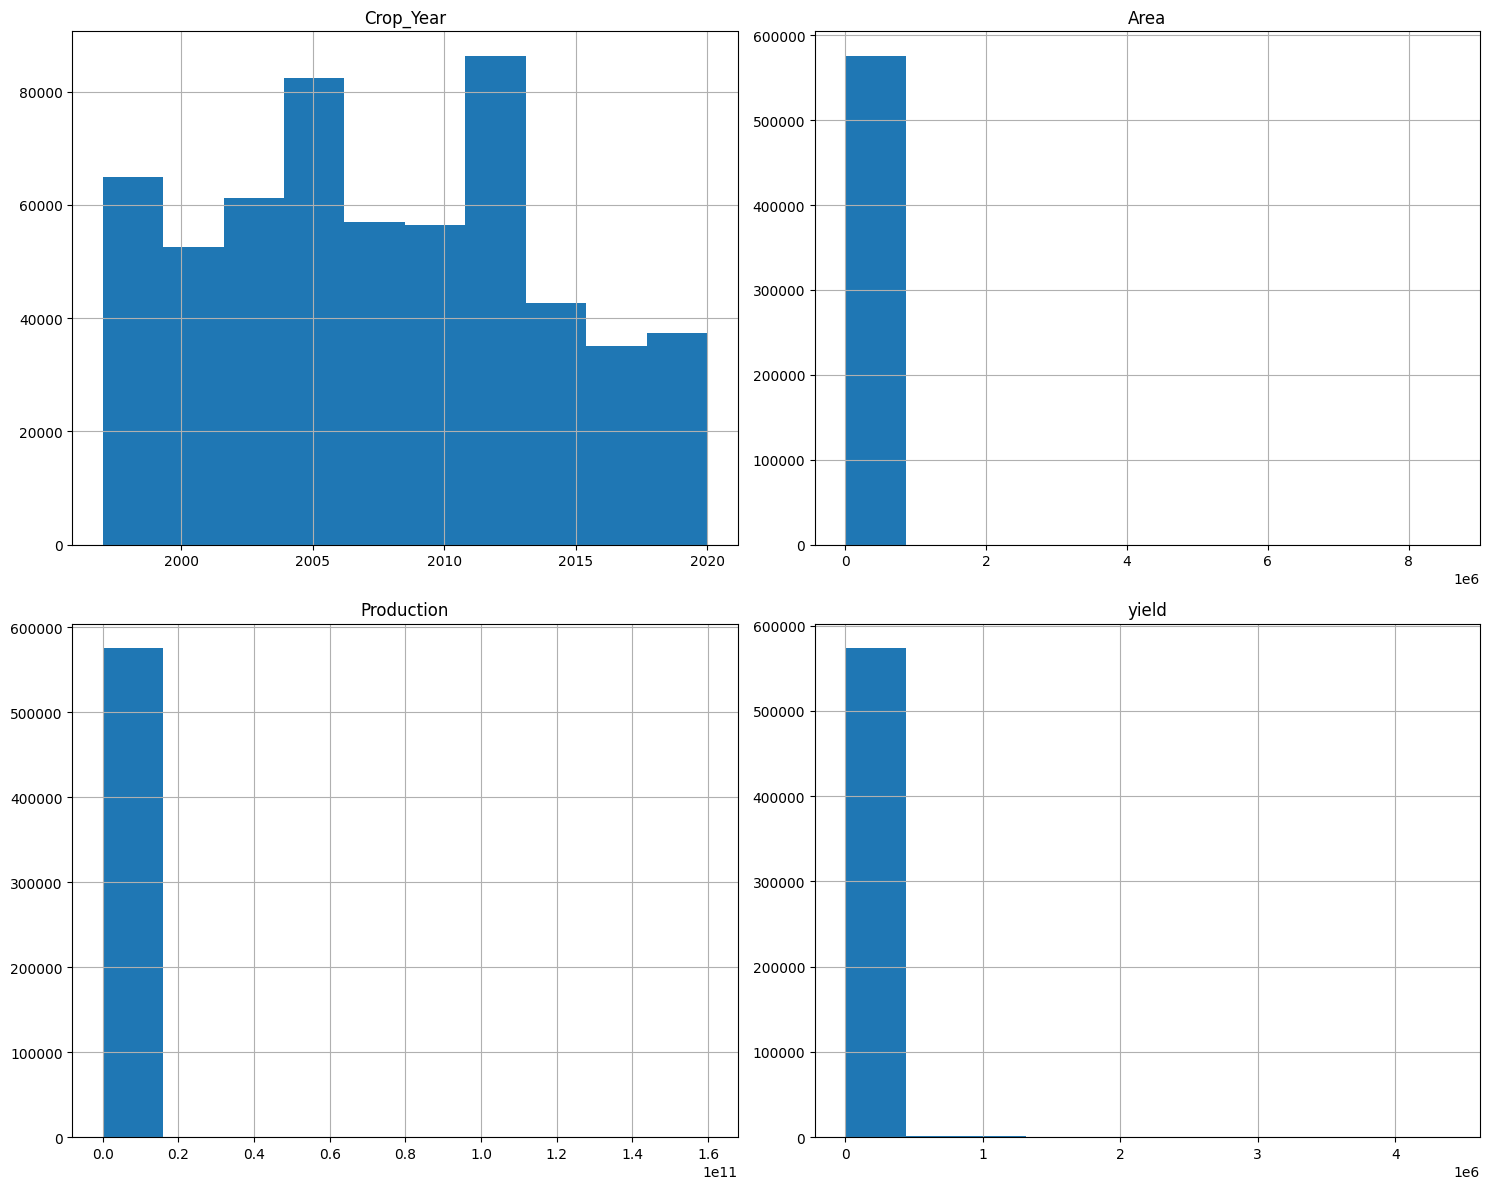

In [ ]:
numeric = df.select_dtypes(include='number')

numeric.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

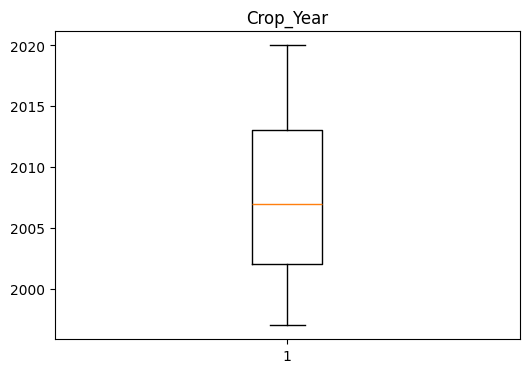

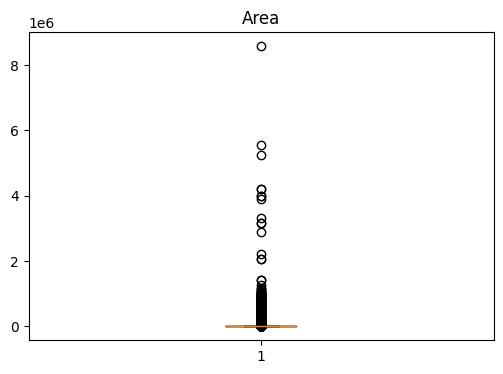

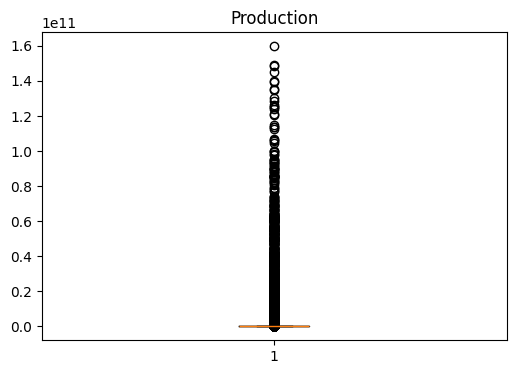

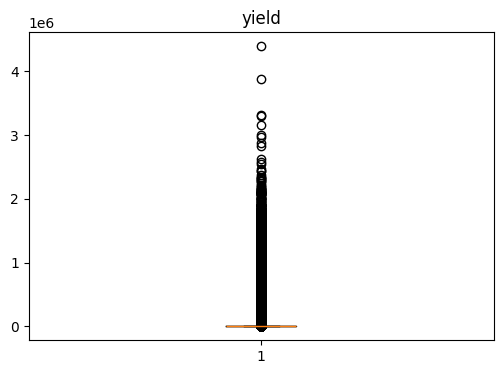

In [ ]:
for column in numeric.columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[column].dropna())

    plt.title(column)

    plt.show()

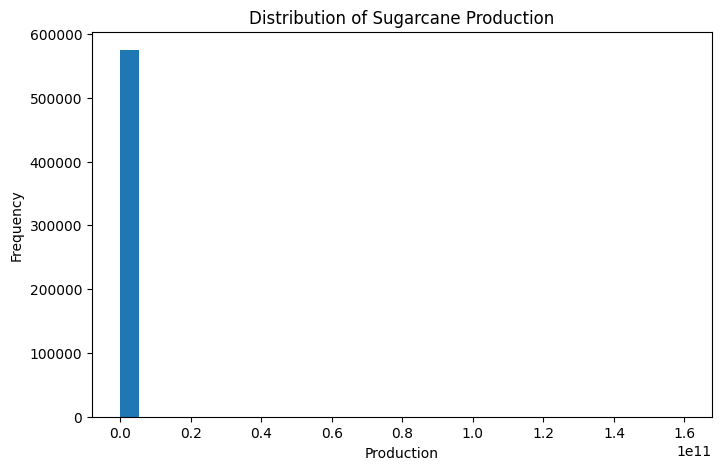

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Production"], bins=30)

plt.xlabel("Production")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Production")

plt.show()

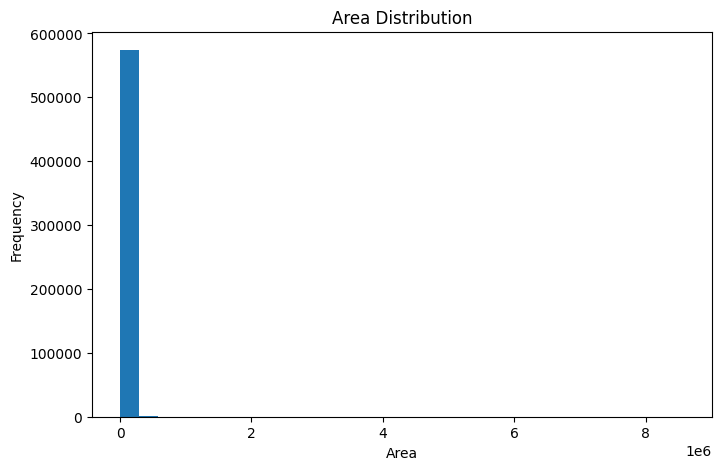

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Area"], bins=30)

plt.xlabel("Area")

plt.ylabel("Frequency")

plt.title("Area Distribution")

plt.show()

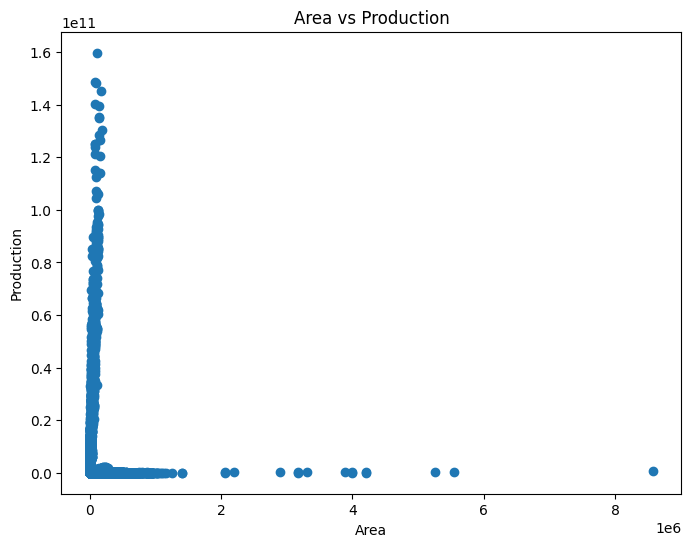

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Area"], df["Production"])

plt.xlabel("Area")

plt.ylabel("Production")

plt.title("Area vs Production")

plt.show()

Yield Distribution

In [ ]:
df["Yield"] = df["Production"] / df["Area"]

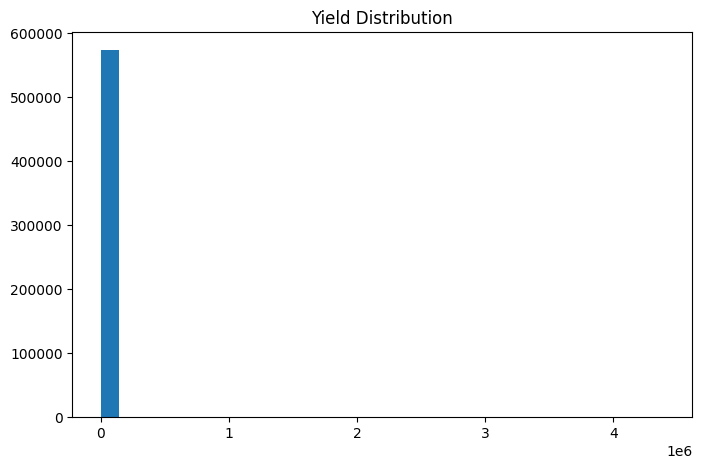

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=30)

plt.title("Yield Distribution")

plt.show()

Production Trend Over Years

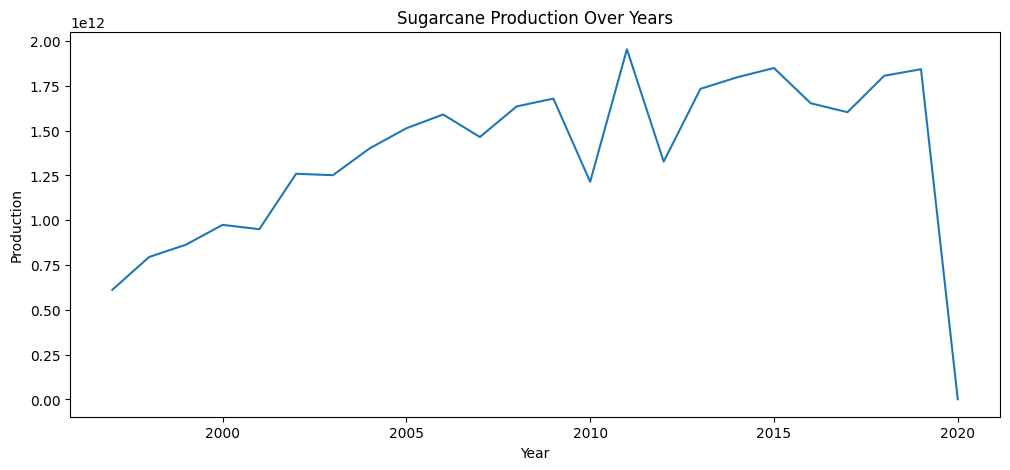

In [ ]:
yearly = df.groupby("Crop_Year")["Production"].sum()

plt.figure(figsize=(12,5))

plt.plot(yearly.index, yearly.values)

plt.xlabel("Year")

plt.ylabel("Production")

plt.title("Sugarcane Production Over Years")

plt.show()

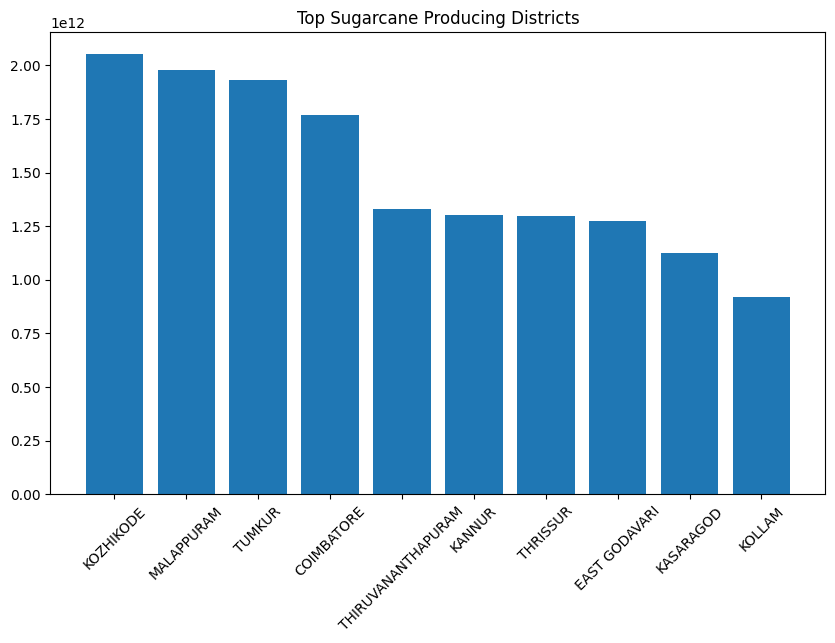

In [ ]:
district = df.groupby("District_Name")["Production"].sum()

district = district.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(district.index, district.values)

plt.xticks(rotation=45)

plt.title("Top Sugarcane Producing Districts")

plt.show()

In [ ]:
corr = numeric.corr()

print(corr)

            Crop_Year      Area  Production     yield
Crop_Year    1.000000 -0.023530    0.010634  0.021415
Area        -0.023530  1.000000    0.039189  0.000058
Production   0.010634  0.039189    1.000000  0.438115
yield        0.021415  0.000058    0.438115  1.000000


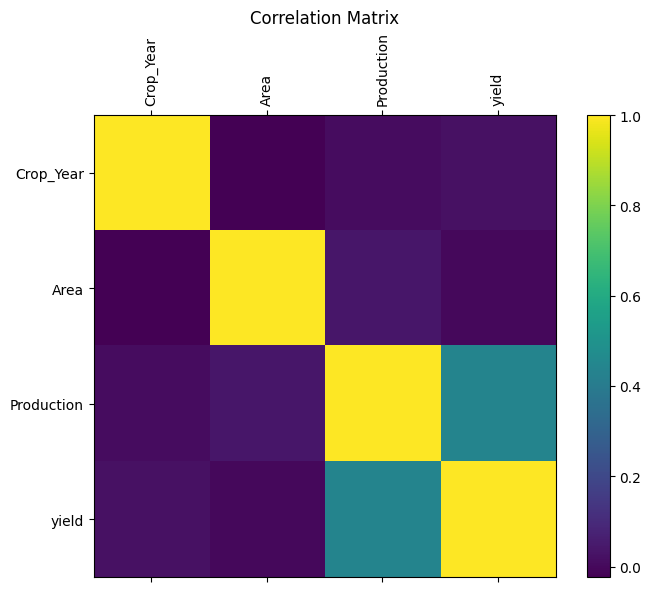

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
print(df[df["Yield"] > df["Yield"].quantile(0.99)])

print(df[df["Area"] == 0])

print(df[df["Production"] == 0])

            State_Name   District_Name  Crop_Year      Season       Crop  \
607     Andhra Pradesh       ANANTAPUR       2006  Whole Year    Coconut   
661     Andhra Pradesh       ANANTAPUR       2008  Whole Year    Coconut   
784     Andhra Pradesh       ANANTAPUR       2011  Whole Year    Coconut   
849     Andhra Pradesh       ANANTAPUR       2012  Whole Year    Coconut   
983     Andhra Pradesh       ANANTAPUR       2014  Whole Year    Coconut   
...                ...             ...        ...         ...        ...   
575576     West Bengal  MEDINIPUR WEST       1998  Whole Year  Sugarcane   
575577     West Bengal  MEDINIPUR WEST       1999  Whole Year  Sugarcane   
575591     West Bengal         PURULIA       1997  Whole Year  Sugarcane   
575592     West Bengal         PURULIA       1998  Whole Year  Sugarcane   
575593     West Bengal         PURULIA       1999  Whole Year  Sugarcane   

          Area  Production         yield         Yield  
607      790.0   6404076.0   8

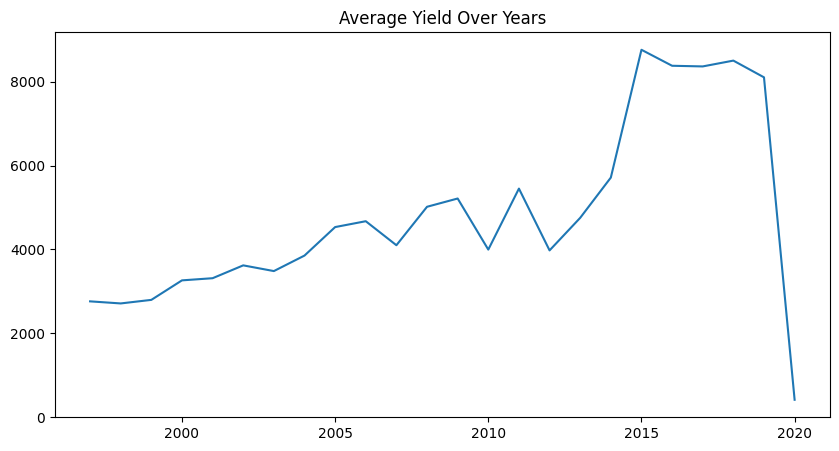

In [ ]:
yield_year = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(10,5))

plt.plot(yield_year.index, yield_year.values)

plt.title("Average Yield Over Years")

plt.show()

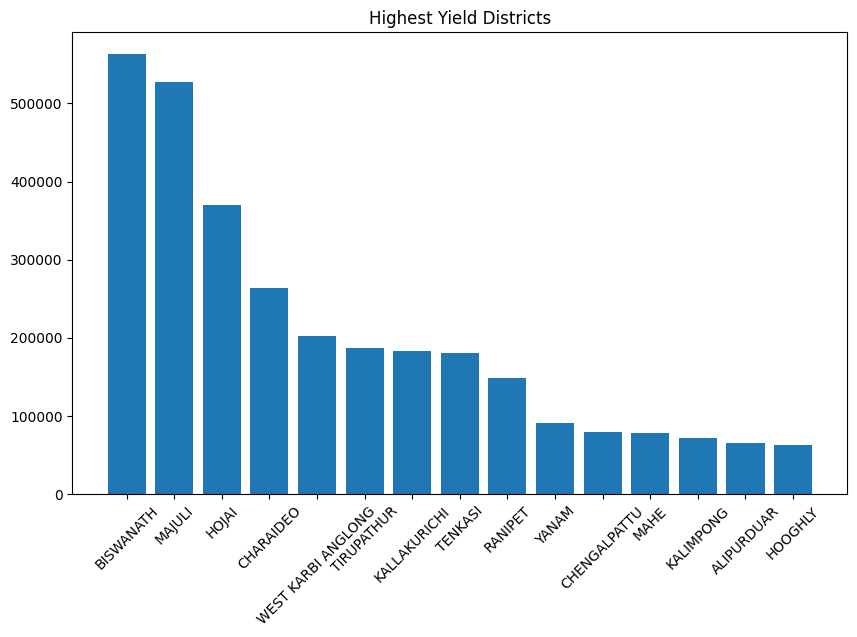

In [ ]:
yield_dist = df.groupby("District_Name")["Yield"].mean()

yield_dist = yield_dist.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

plt.bar(yield_dist.index, yield_dist.values)

plt.xticks(rotation=45)

plt.title("Highest Yield Districts")

plt.show()

In [ ]:
df = df[
    (df["State_Name"] == "Maharashtra") &
    (df["Crop"] == "Sugarcane")
].copy()

print(df.shape)
print(df.head())

In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Production"], bins=30)

plt.xlabel("Production (Tonnes)")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Production in Maharashtra")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Area"], bins=30)

plt.xlabel("Area (Hectares)")

plt.ylabel("Frequency")

plt.title("Distribution of Sugarcane Area in Maharashtra")

plt.show()

In [ ]:
df["Yield"] = df["Production"] / df["Area"]

plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=30)

plt.xlabel("Yield (Tonnes/Hectare)")

plt.ylabel("Frequency")

plt.title("Sugarcane Yield Distribution")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Area"], df["Production"])

plt.xlabel("Area (ha)")

plt.ylabel("Production (Tonnes)")

plt.title("Area vs Sugarcane Production")

plt.show()

In [ ]:

yearly = df.groupby("Crop_Year")["Production"].sum()

plt.figure(figsize=(12,5))

plt.plot(yearly.index, yearly.values, marker='o')

plt.xlabel("Year")

plt.ylabel("Production")

plt.title("Sugarcane Production Trend in Maharashtra")

plt.grid()

plt.show()

In [ ]:
yield_year = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(12,5))

plt.plot(yield_year.index, yield_year.values, marker='o')

plt.xlabel("Year")

plt.ylabel("Average Yield")

plt.title("Average Sugarcane Yield in Maharashtra")

plt.grid()

plt.show()

In [ ]:
district = (
    df.groupby("District_Name")["Production"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(district.index, district.values)

plt.xticks(rotation=45)

plt.ylabel("Production (Tonnes)")

plt.title("Top 10 Sugarcane Producing Districts in Maharashtra")

plt.show()

In [ ]:
yield_dist = (
    df.groupby("District_Name")["Yield"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(yield_dist.index, yield_dist.values)

plt.xticks(rotation=45)

plt.ylabel("Yield (Tonnes/Hectare)")

plt.title("Top 10 Yield-Producing Districts")

plt.show()

In [ ]:

numeric = df[["Area", "Production", "Yield"]]

corr = numeric.corr()

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Yield"])

plt.title("Yield Outliers")

plt.show()

In [ ]:

print(df[df["Area"] <= 0])

print(df[df["Production"] <= 0])

print(df[df["Yield"] <= 0])

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64','float64']).columns

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [ ]:
df = df[df["Area"] > 0]

df = df[df["Production"] > 0]

In [ ]:
df["Yield"] = df["Production"] / df["Area"]


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["District_Name"] = encoder.fit_transform(df["District_Name"])

df["Season"] = encoder.fit_transform(df["Season"])

In [ ]:
X = df.drop(["Yield"], axis=1)

y = df["Yield"]

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
